In [1]:
import pandas as pd

# ==========================================
# 模块 1: ODS层数据读取与脱水 (Data Extraction & Cleaning)
# ==========================================

print("正在读取并清洗智能售货机全量订单数据...")

# 1. 加载数据
# 业务逻辑：真实系统的CSV导出通常包含特殊字符，指定 gbk 编码。
# low_memory=False 是为了防止 Pandas 猜测列的数据类型时因类型不一致而报错。
df = pd.read_csv('D://智子//五一项目//项目二//data//all.csv', encoding='gbk', low_memory=False)

# 2. 剔除无效的幽灵列
# 业务逻辑：系统导出时常常会在末尾多出完全为空的列（如 Unnamed: 14），必须干掉。
cols_to_drop = [col for col in df.columns if 'Unnamed' in col]
if '0' in df.columns:  # 剔除系统自带的无意义序号列
    cols_to_drop.append('0') 
df_cleaned = df.drop(columns=cols_to_drop)

# 3. 核心指标严控：过滤无效订单
# 业务逻辑：退款、卡货、未付款的订单不能算作业绩！我们只看“出货成功”且“实售金额 > 0”的真金白银。
# 注意：先把金额列强制转化为数字，防止被系统识别为字符串。
df_cleaned['实售金额'] = pd.to_numeric(df_cleaned['实售金额'], errors='coerce')
df_cleaned = df_cleaned[(df_cleaned['订单状态'] == '出货成功') & (df_cleaned['实售金额'] > 0)]

# 4. 特征工程：时间维度的降维打击
# 业务逻辑：原表中“日期”和“时间”是分开的两列。必须拼接成标准的 Timestamp 对象。
# 为什么要拼？因为后续我们要分析“早高峰/晚高峰销售曲线”，必须有标准的时间轴！
df_cleaned['订单时间'] = pd.to_datetime(df_cleaned['下单日期'] + ' ' + df_cleaned['下单时间'], errors='coerce')

# 预览一下清洗后的高价值数据
print(f"✅ 清洗完成！剔除了无效订单后，有效交易数为: {len(df_cleaned)} 笔")
print("数据前三行预览:")
print(df_cleaned[['设备编号', '商品名称', '实售金额', '订单时间']].head(3))

正在读取并清洗智能售货机全量订单数据...
✅ 清洗完成！剔除了无效订单后，有效交易数为: 595389 笔
数据前三行预览:
       设备编号                    商品名称  实售金额                订单时间
0  FS100408  焕神[热带水果风味]饮料(PET460ml)   5.0 2023-03-31 22:13:26
1  FS100408  焕神[热带水果风味]饮料(PET460ml)   5.0 2023-03-31 22:13:12
2  FS100408  焕神[热带水果风味]饮料(PET460ml)   5.0 2023-03-31 22:12:56


In [2]:
# ==========================================
# 模块 2: DWS层聚合与商业洞察 (商品动销与贡献度分析)
# ==========================================

print("开始进行商品销售特征聚合分析...")

# 1. 核心聚合计算：按商品分组，计算“销量”和“GMV(总销售额)”
# 业务逻辑：我们不能只看卖了多少瓶（销量），还要看赚了多少钱（销售额）。
# 比如一包辣条卖 1 块钱，卖 100 包才 100 块；但一罐红牛卖 6 块钱，卖 20 罐就超过去了。
product_stats = df_cleaned.groupby('商品名称').agg(
    总销量=('实售金额', 'count'), # 每一行就是一笔成功的订单，count 就是销量
    总销售额=('实售金额', 'sum')   # sum 就是这些订单实售金额的总和
).reset_index()

# 2. 找出“爆款印钞机”（按销售额降序排列，取前10名）
top_10_products = product_stats.sort_values(by='总销售额', ascending=False).head(10)

# 3. 找出“滞销长尾货”（按销售额升序排列，取最后10名）
# 注意：这里我们过滤掉销量太少的极端异常数据（比如总销量不足5件的可能是测试商品）
bottom_candidates = product_stats[product_stats['总销量'] >= 5]
bottom_10_products = bottom_candidates.sort_values(by='总销售额', ascending=True).head(10)

print("\n🏆 【爆款商品 Top 10】(为公司赚最多钱的商品):")
print(top_10_products.to_string(index=False))

print("\n🗑️ 【滞销商品 Bottom 10】(建议优先淘汰或减少排面的商品):")
print(bottom_10_products.to_string(index=False))

# 4. 高阶运营常识：验证“二八定律 (帕累托法则)”
# 业务逻辑：是不是前 20% 的商品，贡献了 80% 的销售额？
total_revenue = product_stats['总销售额'].sum()
total_sku_count = len(product_stats)

# 计算前 20% 的商品数量
top_20_percent_count = int(total_sku_count * 0.2)
top_20_percent_revenue = product_stats.sort_values(by='总销售额', ascending=False).head(top_20_percent_count)['总销售额'].sum()

revenue_ratio = (top_20_percent_revenue / total_revenue) * 100
print(f"\n📊 【商业洞察】: 本次数据共有 {total_sku_count} 款商品(SKU)。")
print(f"其中，排名前 20% 的商品，贡献了整体销售额的 {revenue_ratio:.2f}%！")

开始进行商品销售特征聚合分析...

🏆 【爆款商品 Top 10】(为公司赚最多钱的商品):
                  商品名称   总销量     总销售额
 统一阿萨姆[奶茶原味](PET500ml) 42409 186182.9
     海之言[柠檬](PET500ml) 38137 153286.5
   可口可乐[自购版](PET500ml) 42052 138385.5
   统一冰红茶[柠檬](PET500ml) 43582 131167.5
       统一鲜橙多(PET450ml) 34319 120206.3
     怡宝[纯净水](PET555ml) 48577  97776.0
 统一冰绿茶[青梅绿茶](PET500ml) 31267  94162.0
焕神[热带水果风味]饮料(PET460ml) 17461  87346.4
    统一绿茶[茉莉](PET500ml) 28726  86313.0
  饮养四季[金桔柠檬](PET500ml) 21355  69859.0

🗑️ 【滞销商品 Bottom 10】(建议优先淘汰或减少排面的商品):
                 商品名称  总销量  总销售额
    青云泉天然泉水(PET555ml)    6  12.0
统一轻啵苏打水[原味](PET500ml)   10  35.0
    粤喵喵生榨椰汁(CAN315ml)   11  38.0
     清蓝生椰牛乳(PET380ml)    9  49.5
  怡宝火咖[香浓味](PET180ml)   18  54.0
   统一冰绿茶[青梅绿茶](PET1l)   14  63.0
  娃哈哈[晶莹葡萄](PET500ml)   26  65.0
 小茗同学[冰橘绿茶](PET480ml)   14  70.0
      台福椰子汁(CAN238ml)   28  84.0
  今麦郎蜂蜜柚子味复合果汁饮料500ml   31  93.0

📊 【商业洞察】: 本次数据共有 136 款商品(SKU)。
其中，排名前 20% 的商品，贡献了整体销售额的 83.17%！


In [3]:
# ==========================================
# 模块 3: DWS层聚合 - 时间序列与销售潮汐特征工程 (Time-Series EDA)
# ==========================================
import matplotlib.pyplot as plt
import matplotlib as mpl

# 设置中文字体，防止图表里的中文变成小方块 (Windows通常用SimHei，Mac用Arial Unicode MS)
mpl.rcParams['font.sans-serif'] = ['SimHei'] # 如果你是Mac，请改成 ['Arial Unicode MS']
mpl.rcParams['axes.unicode_minus'] = False 

print("开始提取时间特征，进行全天候销售潮汐分析...")

# 1. 特征工程 (Feature Engineering)：降维打击
# 业务逻辑：原本的“订单时间”精确到秒，这对找规律毫无帮助。我们需要把“小时”和“星期”单独提取出来。
df_cleaned['小时'] = df_cleaned['订单时间'].dt.hour
df_cleaned['星期'] = df_cleaned['订单时间'].dt.dayofweek + 1 # 返回0-6，+1后变成直观的1-7(周一到周日)

# 2. 聚合：计算一天中24小时的销售分布（找全天早晚高峰）
hourly_stats = df_cleaned.groupby('小时')['实售金额'].sum().reset_index()
hourly_stats.columns = ['销售小时', '总销售额']

# 找出销售额最高的前3个“黄金小时”
top_3_hours = hourly_stats.sort_values(by='总销售额', ascending=False).head(3)
print("\n⏰ 【24小时潮汐规律】—— 每天最赚钱的3个小时:")
print(top_3_hours.to_string(index=False))

# 3. 聚合：计算一周7天的销售分布（找工作日 vs 周末的差异）
weekday_stats = df_cleaned.groupby('星期')['实售金额'].sum().reset_index()
weekday_stats.columns = ['星期', '总销售额']

# 找出是一周中最赚钱的一天
best_day = weekday_stats.sort_values(by='总销售额', ascending=False).head(1)
print("\n📅 【一周潮汐规律】—— 每周卖得最好的一天是:")
print(best_day.to_string(index=False))

# ==========================================
# 面试加分项：一段极简的 ASCII 可视化展示趋势 (防止面试官问你不会画图)
# ==========================================
print("\n📊 24小时销售趋势微型图表:")
for index, row in hourly_stats.iterrows():
    hour = int(row['销售小时'])
    sales = row['总销售额']
    # 按照销售额比例打印柱状图，每 5000 块钱打印一个 █
    bar_length = int(sales / 5000) 
    print(f"{hour:02d}时 | {'█' * bar_length} ({sales:.0f}元)")

开始提取时间特征，进行全天候销售潮汐分析...

⏰ 【24小时潮汐规律】—— 每天最赚钱的3个小时:
 销售小时     总销售额
   11 188951.7
   12 172241.1
   15 155923.2

📅 【一周潮汐规律】—— 每周卖得最好的一天是:
 星期     总销售额
  5 375467.5

📊 24小时销售趋势微型图表:
00时 | ███████ (39227元)
01时 | ███ (17548元)
02时 | ███ (16388元)
03时 | ██ (12672元)
04时 | ██ (10464元)
05时 | ████ (24668元)
06时 | █████ (25396元)
07时 | ████████████████ (83459元)
08时 | █████████████ (69409元)
09时 | █████████████████████ (106096元)
10时 | ███████████████████████ (115842元)
11时 | █████████████████████████████████████ (188952元)
12时 | ██████████████████████████████████ (172241元)
13时 | ██████████████████████████ (131064元)
14时 | █████████████████████████████ (149781元)
15时 | ███████████████████████████████ (155923元)
16时 | ████████████████████████ (122676元)
17时 | █████████████████████████ (127044元)
18时 | ████████████████████ (103857元)
19时 | ████████████████ (83334元)
20时 | ████████████████ (81560元)
21时 | ███████████████ (75360元)
22时 | ███████████ (59848元)
23时 | █████████ (46003元)


In [4]:
# ==========================================
# 模块 4: DWS层聚合 - 空间维度与单机坪效分析 (Spatial EDA)
# ==========================================

print("开始进行区域销售对比与单机坪效评估...")

# 1. 区域维度大比拼
# 业务逻辑：公司想扩张，是该去华东还是华南？这需要用数据说话。
region_stats = df_cleaned.groupby('所属区域').agg(
    区域总销售额=('实售金额', 'sum'),
    机器数量=('设备编号', 'nunique'), # nunique 用于计算去重后的设备数
    订单总量=('实售金额', 'count')
).reset_index()

# 计算区域的“单机平均贡献” (这才是衡量区域商业价值的核心指标)
region_stats['单机平均贡献'] = region_stats['区域总销售额'] / region_stats['机器数量']

print("\n🌍 【区域商业价值对比】:")
print(region_stats.sort_values(by='单机平均贡献', ascending=False).to_string(index=False))


# 2. 单机坪效分析 (找出提款机和吃灰机)
# 业务逻辑：找出极高产出的机器去复盘选址经验；找出极低产出的机器考虑撤机或更换点位。
machine_stats = df_cleaned.groupby(['设备编号', '所属区域', '所属线路']).agg(
    单机总销售额=('实售金额', 'sum'),
    单机日均销量=('实售金额', 'count') # 暂时用总单量代替，实际应除以运营天数
).reset_index()

# 找出 Top 5 印钞机
top_5_machines = machine_stats.sort_values(by='单机总销售额', ascending=False).head(5)
print("\n💰 【超级印钞机 Top 5】(建议地推团队去这些机器周围考察人流特征):")
print(top_5_machines.to_string(index=False))

# 找出 Bottom 5 吃灰机 (过滤掉可能是刚投放的极少单量机器，设定门槛为100单)
bottom_5_machines = machine_stats[machine_stats['单机日均销量'] > 100].sort_values(by='单机总销售额', ascending=True).head(5)
print("\n⚠️ 【亏本预警！末尾吃灰机 Bottom 5】(建议重点巡检或准备撤机转点):")
print(bottom_5_machines.to_string(index=False))

开始进行区域销售对比与单机坪效评估...

🌍 【区域商业价值对比】:
 所属区域   区域总销售额  机器数量   订单总量      单机平均贡献
   华北 140541.0    20  39560 7027.050000
   华东 941291.0   176 277046 5348.244318
   东北 533465.0   113 157640 4720.929204
统一区域1  41609.0    12  11416 3467.416667
   华南 238288.6    72  72647 3309.563889
   华中 111152.5    44  33238 2526.193182
   西南  11101.0    12   3435  925.083333
   西北   1361.0     4    407  340.250000

💰 【超级印钞机 Top 5】(建议地推团队去这些机器周围考察人流特征):
    设备编号 所属区域 所属线路  单机总销售额  单机日均销量
FS101408   华东  芜湖三 94453.5   29874
FS101404   华东  芜湖三 50789.0   16364
FS100924   华北  天津富 45673.0   12946
FS100059   华东  扬州斯 43035.0   11880
FS100773   华南  福州众 36221.0   11126

⚠️ 【亏本预警！末尾吃灰机 Bottom 5】(建议重点巡检或准备撤机转点):
    设备编号 所属区域 所属线路  单机总销售额  单机日均销量
FS100138   东北  老边区   300.0     137
FS101277   东北  沈阳随   300.0     101
FS100176   东北  老边区   319.0     145
FS100338   华东  扬州斯   323.0     106
FS100370   华东  马鞍山   334.5     112


In [6]:
import pandas as pd
import glob
import os

# ==========================================
# 模块 5-1: 自动化批量读取与清洗 (Batch ETL Pipeline)
# ==========================================
print("开始执行批量库存数据抓取与清洗作业...")

# 1. 批量寻找文件
# 业务逻辑：每天系统可能会导出好几个库存快照文件，我们不能傻傻地一个个手动读，用 glob 一网打尽。
file_paths = glob.glob('D://智子//五一项目//项目二//data//库存明细*.csv') # 自动抓取当前目录下所有以“库存明细”开头的csv
print(f"✅ 发现 {len(file_paths)} 个库存碎片文件，正在进行合并...")

# 2. 循环读取并合并 (Concat)
df_inv_list = []
for file in file_paths:
    # 工业级防雷：一定要指定编码，并忽略错误，防止某个坏文件搞崩整个程序
    temp_df = pd.read_csv(file, encoding='gbk', on_bad_lines='skip') 
    df_inv_list.append(temp_df)

# 将所有小表格上下拼接成一张大表（全量库存表）
df_inventory = pd.concat(df_inv_list, ignore_index=True)

# 3. 极其关键的清洗：剔除“反人类”的特殊字符
# 业务逻辑：你仔细看原始库存数据，设备编号前面带了个奇怪的符号 ` (比如 `FS100313)
# 这是因为导出系统为了防止Excel把编号变成科学计数法强加的。如果不洗掉它，后面关联(Join)绝对失败！
df_inventory['设备编号'] = df_inventory['设备编号'].astype(str).str.replace('`', '')

# 4. 聚合当前库存
# 业务逻辑：一台机器里，同一种饮料可能放在好几个货道里（比如货道1和货道2都是可乐）。
# 我们要算的是这台机器“总共”还有多少瓶可乐。
current_stock = df_inventory.groupby(['设备编号', '商品名称'])['可售库存'].sum().reset_index()

print(f"✅ 库存快照清洗完毕！共提取了 {len(current_stock)} 条独立 SKU 的库存记录。")

开始执行批量库存数据抓取与清洗作业...
✅ 发现 7 个库存碎片文件，正在进行合并...
✅ 库存快照清洗完毕！共提取了 11412 条独立 SKU 的库存记录。


In [7]:
# ==========================================
# 模块 5-2: 跨表联动与智能预警算法 (Predictive Stockout Alert)
# ==========================================
print("\n开始计算商品销售流速(Run Rate)，生成断货预警清单...")

# 1. 计算每个商品在每台机器上的“流速”（日均销量）
# 业务逻辑：假设我们的数据跨度大致为30天(你可以根据真实天数调整)。
# 流速 = 总销量 / 30天
sales_velocity = df_cleaned.groupby(['设备编号', '商品名称']).agg(总销量=('实售金额', 'count')).reset_index()
sales_velocity['日均销量(流速)'] = sales_velocity['总销量'] / 30

# 2. 核心大招：事实表与快照表的 Join 融合 (Left Join)
# 业务逻辑：用库存表去匹配销售流速表，把“还能卖多少”和“每天卖多少”拼在同一行。
merged_data = pd.merge(current_stock, sales_velocity, on=['设备编号', '商品名称'], how='left')

# 防雷处理：如果有个商品在库存里，但历史上没卖过（流速为NaN），我们补全为 0.1 (避免除以0报错)
merged_data['日均销量(流速)'] = merged_data['日均销量(流速)'].fillna(0.1)

# 3. 算法输出：计算“预计断货天数” (Days of Supply, DOS)
# 核心公式：还能活几天 = 当前库存数量 / 每天卖出去的数量
merged_data['预计断货天数'] = merged_data['可售库存'] / merged_data['日均销量(流速)']

# 4. 输出工单：过滤出“极危”名单 (预计2天内断货，且不是僵尸商品)
# 指导线下运维小哥马上行动！
urgent_alerts = merged_data[
    (merged_data['预计断货天数'] <= 2.0) & 
    (merged_data['日均销量(流速)'] > 0.5) # 每天至少能卖半瓶以上，证明有真实需求
].sort_values(by='预计断货天数', ascending=True)

print("\n🚨 【智能补货工单：24-48小时内断货高危预警】(请立刻派单给地推团队):")
# 我们只展示前10条最危急的
print(urgent_alerts[['设备编号', '商品名称', '可售库存', '日均销量(流速)', '预计断货天数']].head(10).to_string(index=False))


开始计算商品销售流速(Run Rate)，生成断货预警清单...

🚨 【智能补货工单：24-48小时内断货高危预警】(请立刻派单给地推团队):
    设备编号                   商品名称  可售库存  日均销量(流速)    预计断货天数
FS100082         农夫山泉(PET550ml)    -6  4.400000 -1.363636
FS100774 焕神[热带水果风味]饮料(PET460ml)     0  2.733333  0.000000
FS100772  统一阿萨姆[奶茶原味](PET500ml)     0  3.333333  0.000000
FS100768  统一阿萨姆[奶茶原味](PET500ml)     0  5.800000  0.000000
FS100732  统一阿萨姆[奶茶原味](PET500ml)     0  4.800000  0.000000
FS100727         农夫山泉(PET550ml)     0  9.133333  0.000000
FS100727   今麦郎芒顿小镇蜜桃水(PET500ml)     0  4.200000  0.000000
FS100724  统一阿萨姆[奶茶原味](PET500ml)     0  2.066667  0.000000
FS100724         百事可乐(CAN330ml)     0  2.366667  0.000000
FS100724    可口可乐[自购版](PET500ml)     0  1.200000  0.000000


In [8]:
# ==========================================
# 模块 6-A: 购物篮关联分析 (Market Basket Analysis)
# ==========================================
import pandas as pd
from itertools import combinations

print("开始挖掘商品连带购买规则 (购物篮分析)...")

# 1. 重新定义“订单 / 购物篮”
# 业务逻辑：自动售货机没有明确的“购物车”概念。我们把同一台机器，5分钟内卖出的商品，算作一单！
# dt.floor('5T') 的意思是把时间向下取整到最近的 5 分钟（比如 12:03 和 12:04 都会变成 12:00）
df_cleaned['时间窗口'] = df_cleaned['订单时间'].dt.floor('5T')

# 2. 将同一个购物篮里的商品打包成列表
baskets = df_cleaned.groupby(['设备编号', '时间窗口'])['商品名称'].apply(list).reset_index()

# 3. 只保留买了 2 件及以上商品的“大单”
baskets = baskets[baskets['商品名称'].apply(len) > 1]
print(f"筛选出包含多件商品的真实购物篮共计: {len(baskets)} 个")

# 4. 统计“经常一起被买走”的商品组合 (共现矩阵思想)
pair_counts = {}
for items in baskets['商品名称']:
    # 去重，防止同一个人连买两瓶一样的水干扰分析
    unique_items = list(set(items))
    if len(unique_items) > 1:
        # 生成两两组合
        for pair in combinations(sorted(unique_items), 2):
            pair_counts[pair] = pair_counts.get(pair, 0) + 1

# 5. 转化为 DataFrame 并找出最强 CP
df_pairs = pd.DataFrame(list(pair_counts.items()), columns=['商品组合', '共同购买次数'])
df_pairs = df_pairs.sort_values(by='共同购买次数', ascending=False)

print("\n🛒 【最强商品连带购买 CP Top 5】(建议将这两款商品放在相邻货道):")
print(df_pairs.head(5).to_string(index=False))

开始挖掘商品连带购买规则 (购物篮分析)...
筛选出包含多件商品的真实购物篮共计: 145418 个

🛒 【最强商品连带购买 CP Top 5】(建议将这两款商品放在相邻货道):
                                        商品组合  共同购买次数
      (统一冰红茶[柠檬](PET500ml), 统一鲜橙多(PET450ml))    2288
(统一冰红茶[柠檬](PET500ml), 统一冰绿茶[青梅绿茶](PET500ml))    1987
        (怡宝[纯净水](PET555ml), 统一鲜橙多(PET450ml))    1939
   (统一冰红茶[柠檬](PET500ml), 统一绿茶[茉莉](PET500ml))    1886
    (怡宝[纯净水](PET555ml), 统一冰红茶[柠檬](PET500ml))    1830



正在生成高管 BI 汇报图表...


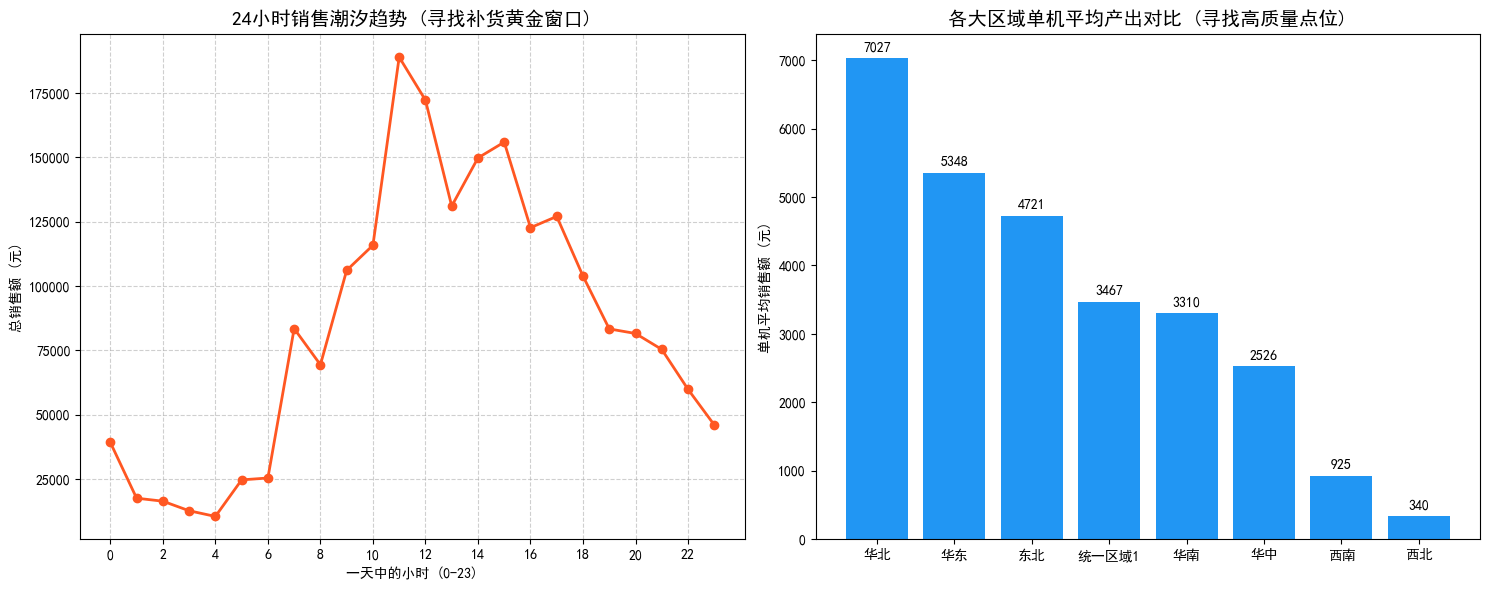

✅ BI 图表渲染完成！你可以截图保存用于汇报。


In [9]:
# ==========================================
# 模块 6-B: BI 可视化大屏生成 (Data Visualization)
# ==========================================
import matplotlib.pyplot as plt
import matplotlib as mpl

# 设置中文字体 (防止方块乱码)
mpl.rcParams['font.sans-serif'] = ['SimHei'] # Mac用户若报错请改为 'Arial Unicode MS'
mpl.rcParams['axes.unicode_minus'] = False 

print("\n正在生成高管 BI 汇报图表...")

# 创建一个 1行2列 的画布
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 图表 1: 每天最赚钱的黄金时间段 (折线图)
# 使用我们在 Step 3 跑出的 hourly_stats (如果不在内存了，这里重新算一次)
hourly_trend = df_cleaned.groupby(df_cleaned['订单时间'].dt.hour)['实售金额'].sum()
axes[0].plot(hourly_trend.index, hourly_trend.values, marker='o', color='#FF5722', linewidth=2)
axes[0].set_title('24小时销售潮汐趋势 (寻找补货黄金窗口)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('一天中的小时 (0-23)')
axes[0].set_ylabel('总销售额 (元)')
axes[0].grid(True, linestyle='--', alpha=0.6)
axes[0].set_xticks(range(0, 24, 2))

# 图表 2: 各大区单机坪效对比 (柱状图)
# 重新计算单机贡献（假设之前 region_stats 不在内存）
region_sales = df_cleaned.groupby('所属区域')['实售金额'].sum()
region_machines = df_cleaned.groupby('所属区域')['设备编号'].nunique()
region_avg = (region_sales / region_machines).sort_values(ascending=False)

axes[1].bar(region_avg.index, region_avg.values, color='#2196F3')
axes[1].set_title('各大区域单机平均产出对比 (寻找高质量点位)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('单机平均销售额 (元)')
for i, v in enumerate(region_avg.values):
    axes[1].text(i, v + 100, f"{v:.0f}", ha='center', fontsize=10) # 在柱子上打标签

plt.tight_layout()
plt.show()
print("✅ BI 图表渲染完成！你可以截图保存用于汇报。")